# XI. sales.csv — Dữ liệu doanh thu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


## 1. Tổng quan

In [3]:
sales_df.head(10)

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
5,2012-07-09,3548386.46,2787841.68
6,2012-07-10,5234938.62,4044438.84
7,2012-07-11,5582884.78,4338313.07
8,2012-07-12,5734632.02,4458811.27
9,2012-07-13,5309511.71,4143402.78


In [4]:
sales_df.shape

(3833, 3)

In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[ns]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 90.0 KB


## 1.1. Phân tích đơn biến

### 1. Trend theo thời gian

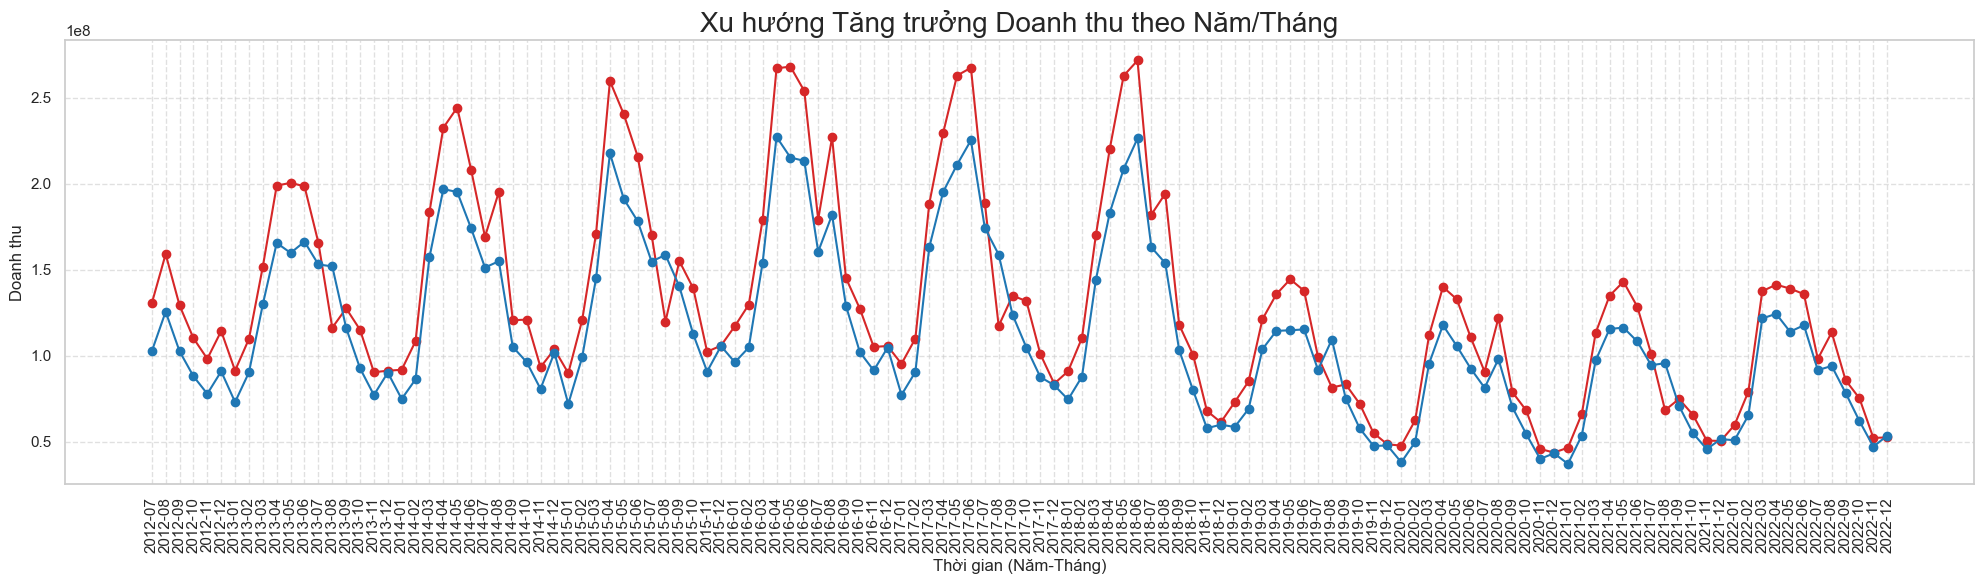

In [11]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Tạo các cột thời gian để phân tích
sales_df['year_month'] = sales_df['Date'].dt.to_period('M')      # Lấy Năm-Tháng
sales_df['day_of_week'] = sales_df['Date'].dt.dayofweek          # Lấy Thứ (0=Thứ 2, 6=Chủ nhật)
sales_df['month'] = sales_df['Date'].dt.month                    # Lấy Tháng (1 đến 12)

# Tổng hợp Doanh thu theo Năm/Tháng
trend_df = sales_df.groupby('year_month')[['Revenue', 'COGS']].sum().reset_index()
trend_df['year_month'] = trend_df['year_month'].astype(str) # Ép kiểu chuỗi để vẽ trục X đẹp hơn

fig1, ax1 = plt.subplots(figsize=(20, 6))

ax1.plot(trend_df['year_month'], trend_df['Revenue'], color='tab:red', marker='o', linestyle='-')
ax1.plot(trend_df['year_month'], trend_df['COGS'], color='tab:blue', marker='o', linestyle='-')
ax1.set_title('Xu hướng Tăng trưởng Doanh thu theo Năm/Tháng', fontsize=20)
ax1.set_xlabel('Thời gian (Năm-Tháng)')
ax1.set_ylabel('Doanh thu')
ax1.tick_params(axis='x', rotation=90)
ax1.grid(True, linestyle='--', alpha=0.6)

fig1.tight_layout()
plt.show()


### 2. Phân bố theo thành phần thời gian 

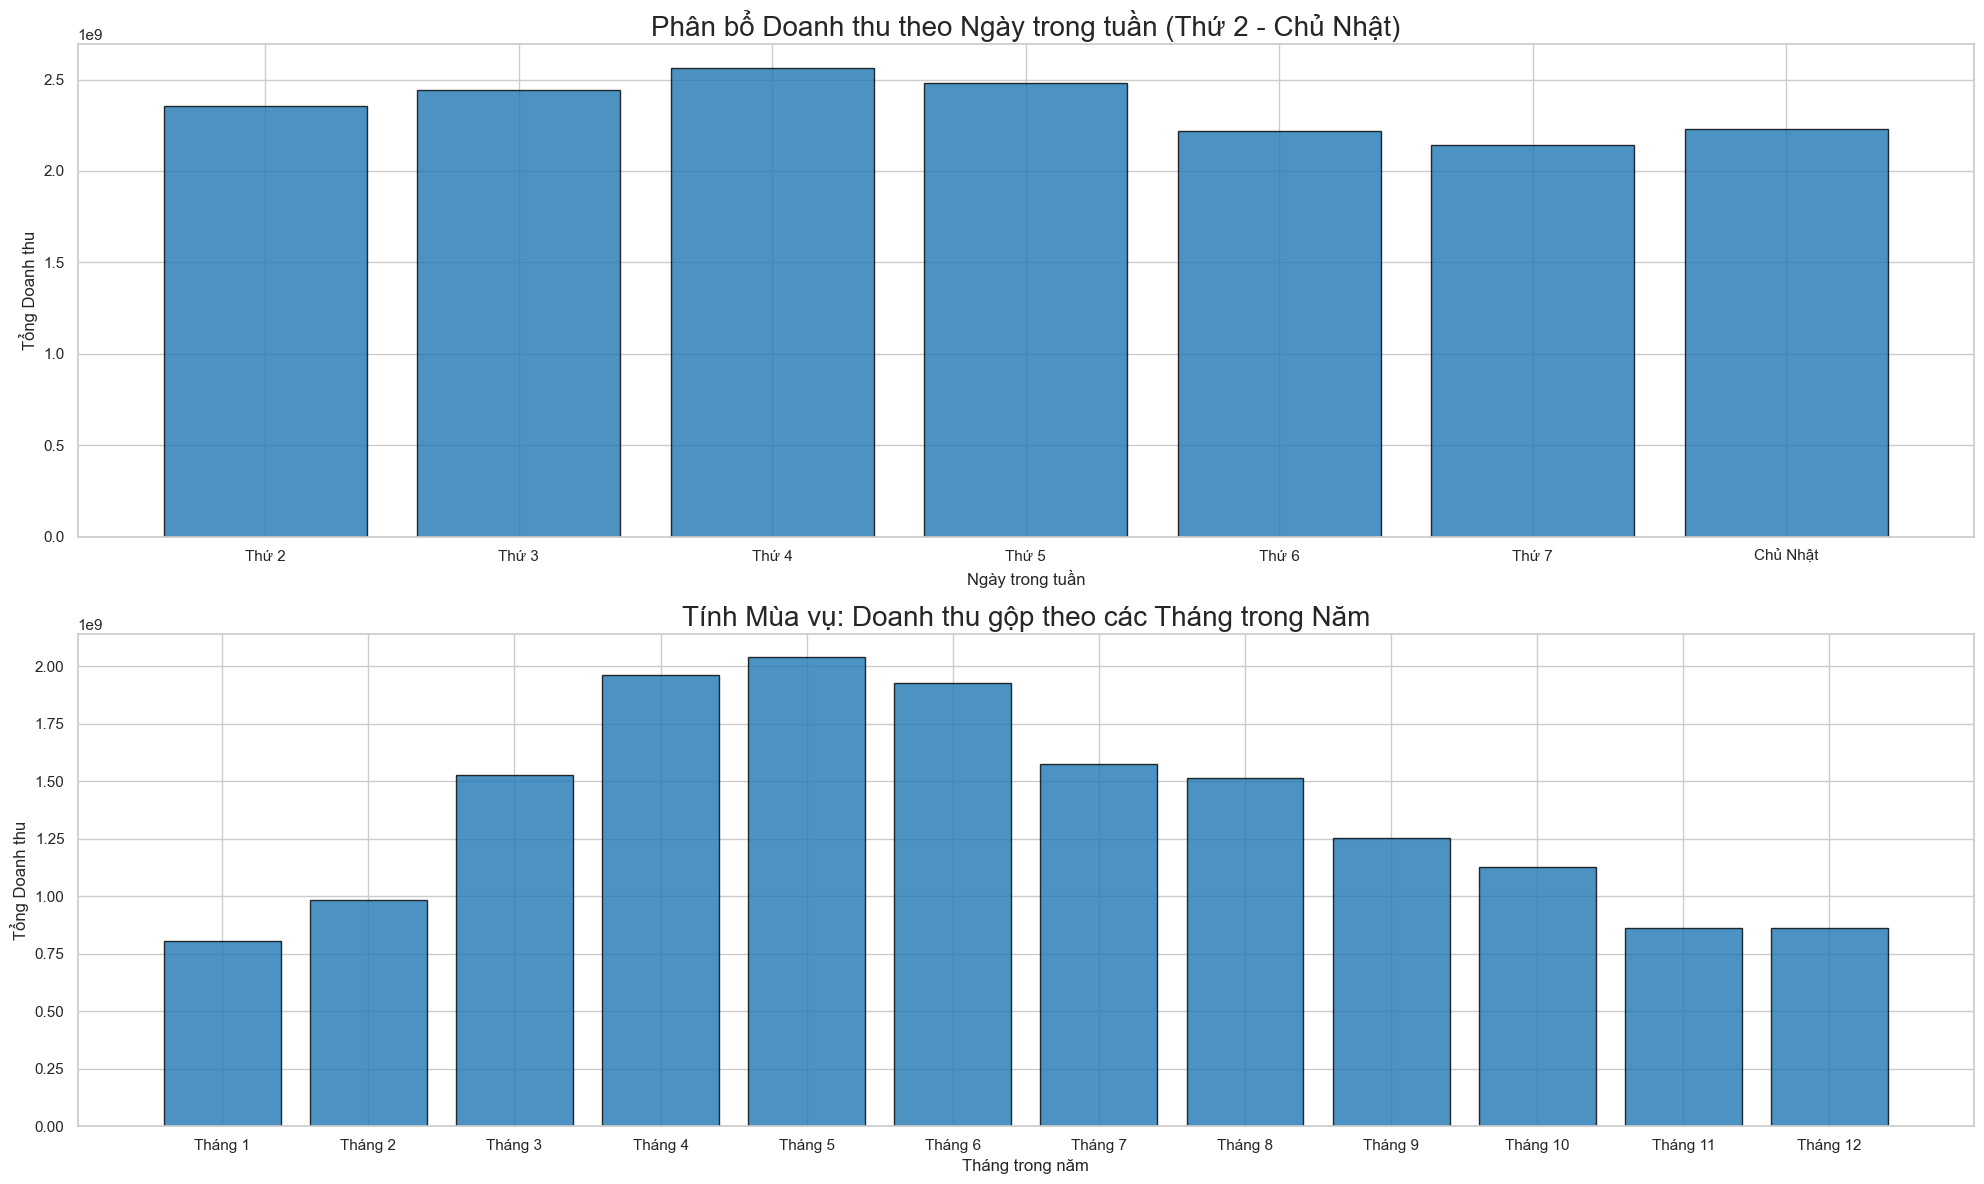

In [ ]:

# --- 1. Tổng hợp dữ liệu theo Ngày trong tuần ---
dow_df = sales_df.groupby('day_of_week')['Revenue'].sum().reset_index()
days_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
dow_df['day_name'] = dow_df['day_of_week'].map(days_map)

# --- 2. Tổng hợp dữ liệu theo Mùa vụ (Tháng trong năm) ---
season_df = sales_df.groupby('month')['Revenue'].sum().reset_index()
months = ['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6', 
          'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12']

fig2, axes = plt.subplots(2, 1, figsize=(20, 12))

# Đồ thị trên: Phân bổ theo Ngày trong tuần
axes[0].bar(dow_df['day_name'], dow_df['Revenue'], color='tab:blue', edgecolor='black', alpha=0.8)
axes[0].set_title('Phân bổ Doanh thu theo Ngày trong tuần (Thứ 2 - Chủ Nhật)', fontsize=20)
axes[0].set_xlabel('Ngày trong tuần')
axes[0].set_ylabel('Tổng Doanh thu')

# Đồ thị dưới: Phân bổ theo Mùa vụ / Tháng
axes[1].bar(months, season_df['Revenue'], color='tab:blue', edgecolor='black', alpha=0.8)
axes[1].set_title('Tính Mùa vụ: Doanh thu gộp theo các Tháng trong Năm', fontsize=20)
axes[1].set_xlabel('Tháng trong năm')
axes[1].set_ylabel('Tổng Doanh thu')

fig2.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
    - **Xu hướng Doanh thu (Year/Month Trend):** Biểu đồ dạng đường (Line chart) thể hiện sự biến động rất mạnh và liên tục qua các năm (từ 2012 đến 2022). Xuất hiện các đỉnh chu kỳ rõ rệt, thường vọt lên mức trên 2.0 - 2.5 x 10^8. Tuy nhiên, biên độ của các đỉnh và nền doanh thu chung có xu hướng giảm dần trong giai đoạn từ 2020 đến 2022 so với thời kỳ "hoàng kim" 2015-2018.
    - **Phân bổ theo Ngày trong tuần:** Dữ liệu phân bổ khá đồng đều, không có sự chênh lệch cực đoan. Tuy nhiên, nhóm ngày giữa tuần (Thứ 3, Thứ 4, Thứ 5) ghi nhận doanh thu nhỉnh hơn rõ rệt, trong đó Thứ 4 đạt đỉnh cao nhất (> 2.5 x 10^9). Nhóm cuối tuần (Thứ 7, Chủ Nhật) có doanh thu thấp hơn phần còn lại nhưng vẫn duy trì ở mức ổn định.
    - **Tính mùa vụ (Seasonality):** Biểu đồ doanh thu gộp theo tháng có hình dáng phân phối gần giống hình chuông, thể hiện tính mùa vụ cực kỳ mạnh. Doanh thu bắt đầu tăng từ Tháng 1, tạo thành một "mùa cao điểm" khổng lồ rơi trọn vào Quý 2 và đầu Quý 3 (Tháng 4, 5, 6 - đỉnh điểm là Tháng 5 với > 2.0 x 10^9), sau đó trượt dốc đều về cuối năm. Các tháng trũng nhất là Tháng 1, 11 và 12.

- **Insights:**
    - **Đặc thù sản phẩm/Hành vi khách hàng:** Tính mùa vụ tập trung vào giữa năm (Tháng 4-6) ám chỉ danh mục sản phẩm này có thể liên quan mật thiết đến mùa hè, du lịch, hoặc các dự án công việc giữa năm. Việc khách hàng chốt đơn nhiều vào giữa tuần (Thứ 3-5) thay vì cuối tuần gợi ý đây có thể là mô hình B2B (mua sắm phục vụ công việc) hoặc nhóm khách hàng mục tiêu ưu tiên nghỉ ngơi, ít tương tác mua sắm trực tuyến vào cuối tuần.
    - **Cảnh báo về tăng trưởng dài hạn:** Xu hướng suy giảm tổng thể từ năm 2020 trở đi là một tín hiệu đỏ. Điều này có thể bắt nguồn từ yếu tố vĩ mô (ảnh hưởng đại dịch, suy thoái kinh tế) hoặc do vòng đời sản phẩm cốt lõi đang bước vào giai đoạn bão hòa, mất dần sức hút.
    - **Rủi ro dòng tiền và vận hành:** Việc phụ thuộc quá lớn vào Quý 2 tạo ra áp lực cực lớn cho dòng tiền. Nếu chiến dịch mùa hè thất bại, doanh nghiệp có thể không đạt mục tiêu cả năm. Ngược lại, chi phí cố định (nhân sự, kho bãi) trong các tháng vùng trũng (Q1, Q4) sẽ ăn mòn lợi nhuận nếu không được tối ưu.

- **Gợi ý hành động:** 
    - **Phân tích Chẩn đoán (Diagnostic Analysis):** Cần "drill-down" (phân tích sâu) vào tập dữ liệu từ năm 2020 - 2022 để tìm ra nguyên nhân cốt lõi của sự sụt giảm. Chia cắt (slice & dice) dữ liệu theo danh mục sản phẩm, phân khúc khách hàng (New vs. Returning) và khu vực địa lý để xem mảng nào đang "kéo chân" đà tăng trưởng tổng thể.
    - **Phân tích Nhị biến & Đa biến (Bivariate/Multivariate Analysis):** Tiến hành phân tích chéo giữa biến "Tháng" hoặc "Ngày trong tuần" với các biến số khác như "Chi phí Marketing", "Số lượng truy cập (Traffic)" và "Tỷ lệ chiết khấu (Discount)". Điều này giúp xác định xem doanh thu cao vào Thứ 4 và Tháng 5 là do nhu cầu tự nhiên (Organic Demand) hay do doanh nghiệp đang dồn quá nhiều ngân sách khuyến mãi vào các thời điểm này.
    - **Phân tích Dự báo (Predictive Analysis):** Khai thác tính chu kỳ rất mạnh của tập dữ liệu này bằng cách áp dụng các mô hình dự báo chuỗi thời gian (Time-Series Forecasting như ARIMA, SARIMA hoặc Prophet). Từ đó, dự báo sản lượng bán ra cho từng tháng/tuần tiếp theo để phòng thu mua có kế hoạch nhập hàng chính xác, tránh tồn kho chết (dead stock) vào cuối năm hoặc cháy hàng (stockout) vào tháng 5.
    - **Chiến lược Kinh doanh/Vận hành:** Cân đối lại dòng doanh thu bằng cách phát triển/nhập thêm các dòng sản phẩm có tính mùa vụ bù trừ (ví dụ: sản phẩm mùa đông/cuối năm) để kích cầu vào các tháng trũng (Tháng 11, 12, 1). Đồng thời, dồn toàn lực vận hành, CSKH và Logistics vào các ngày Thứ 3, 4, 5 hàng tuần để đảm bảo trải nghiệm mua sắm mượt mà nhất khi lượng đơn đổ về đỉnh điểm.

### 2. Phân phối theo thành phần date

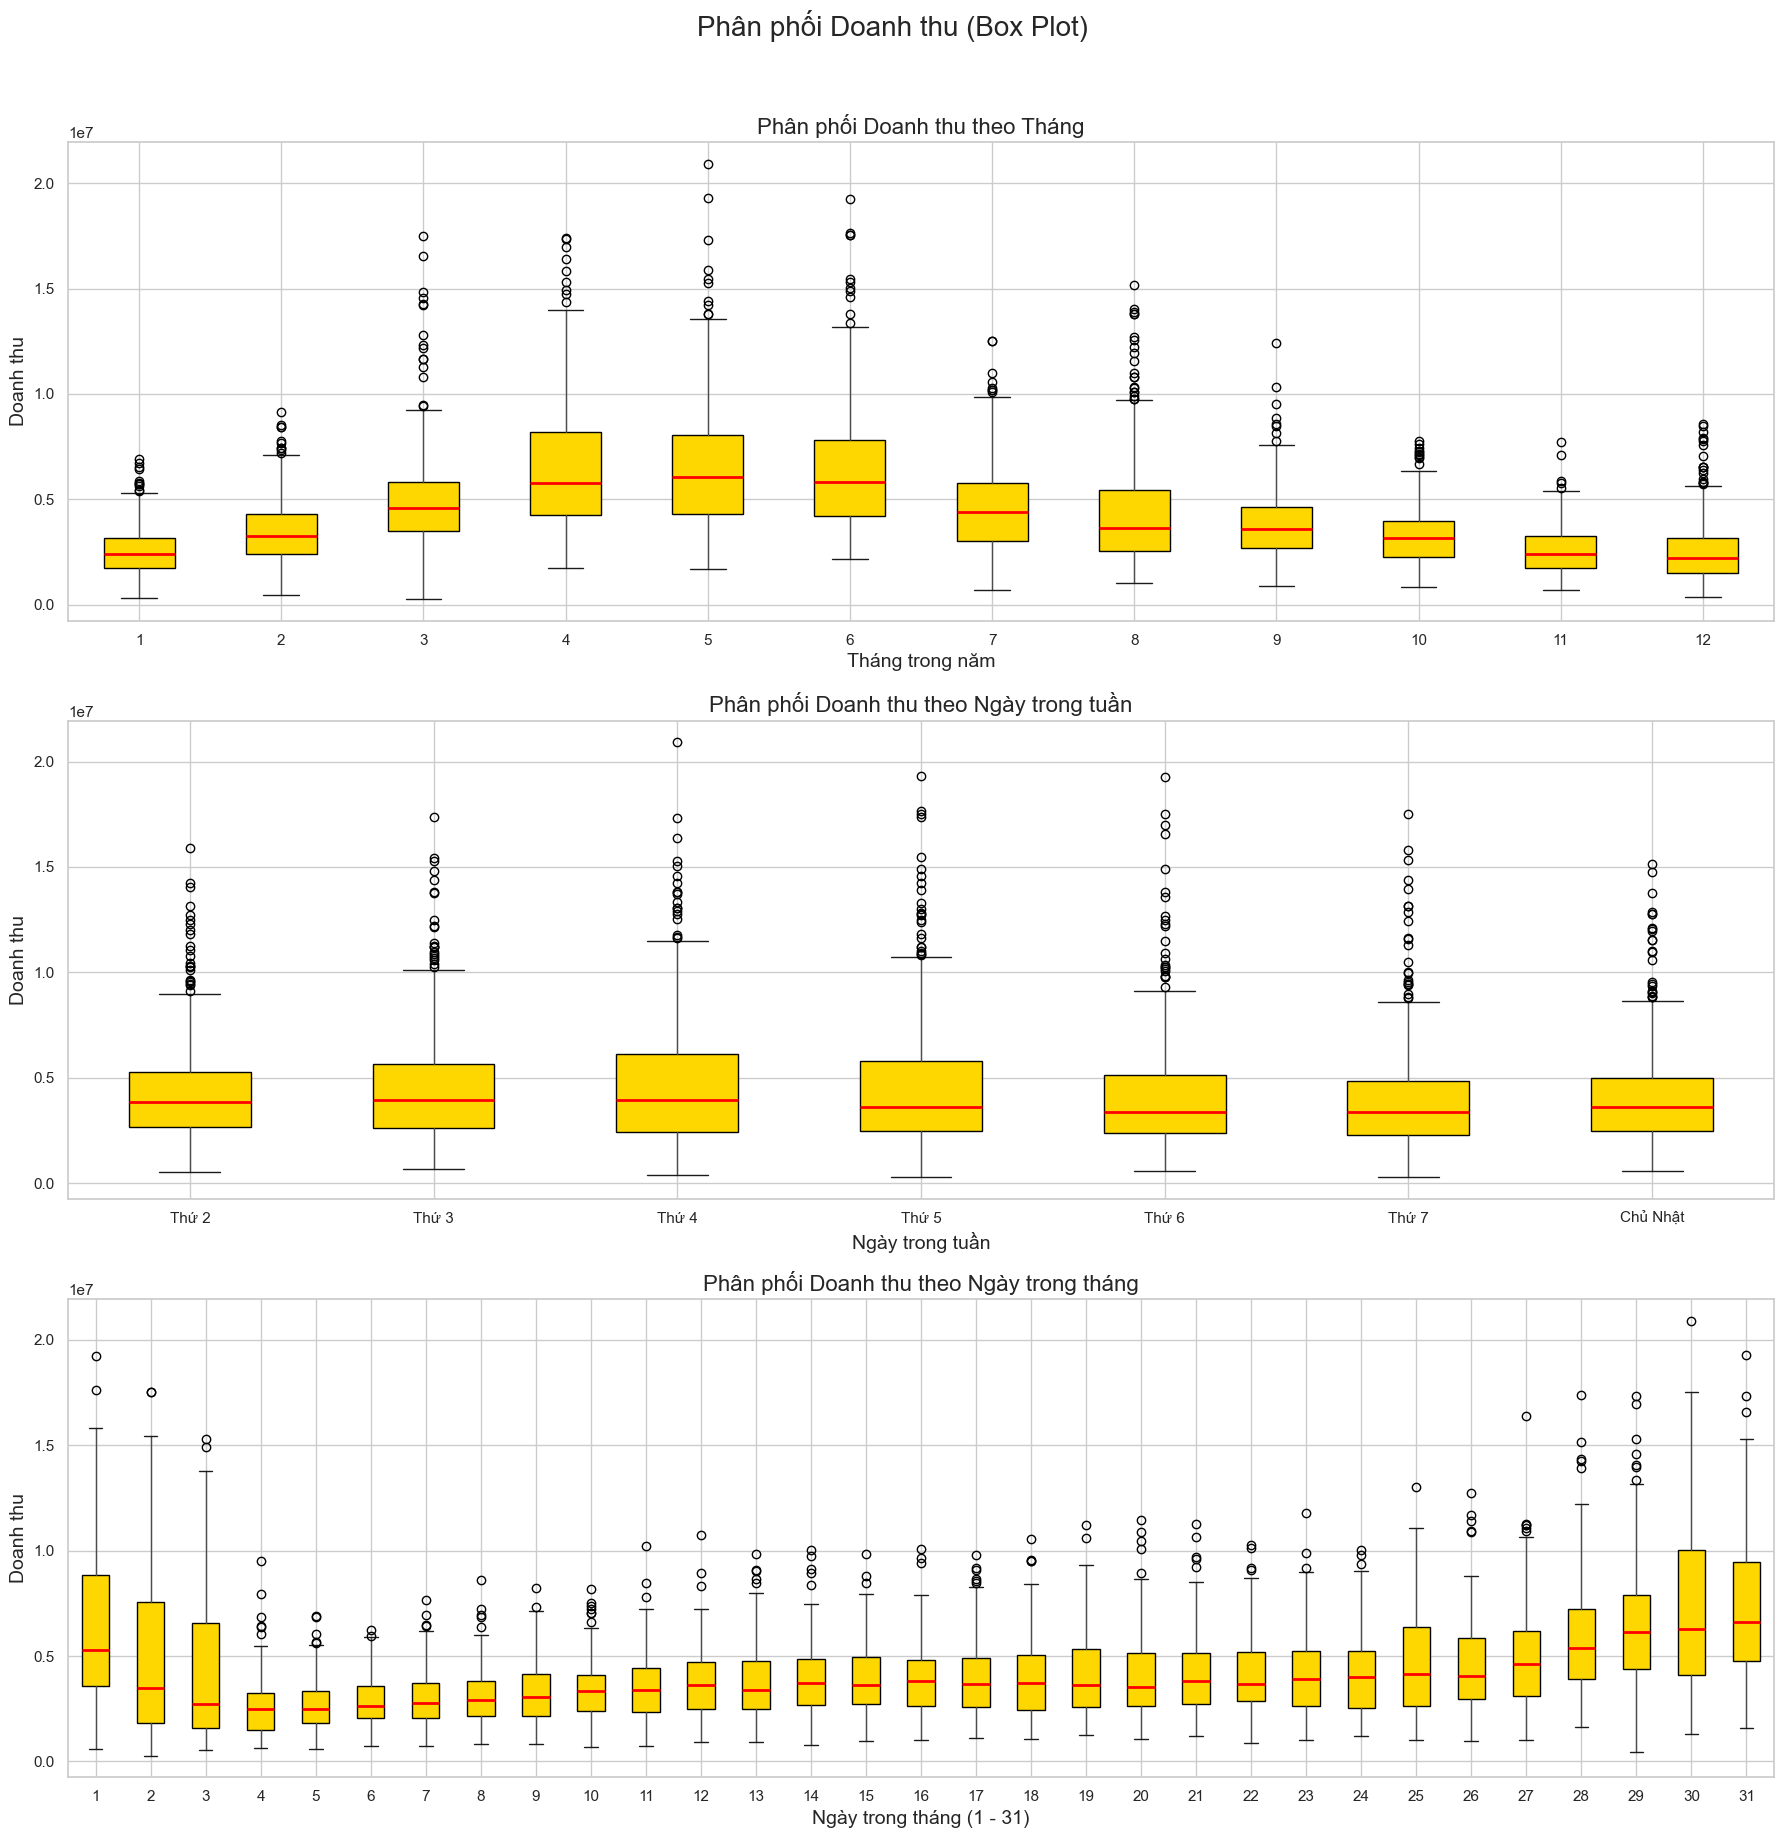

In [ ]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Trích xuất các thuộc tính thời gian
sales_df['month'] = sales_df['Date'].dt.month               # Tháng (1-12)
sales_df['day_of_week'] = sales_df['Date'].dt.dayofweek     # Ngày trong tuần (0-6)
sales_df['day'] = sales_df['Date'].dt.day                   # Ngày trong tháng (1-31)

# Map ngày trong tuần từ số sang chữ
days_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
sales_df['day_name'] = sales_df['day_of_week'].map(days_map)

# Ép kiểu day_name thành Categorical để giữ đúng thứ tự từ Thứ 2 đến Chủ nhật trên biểu đồ
sales_df['day_name'] = pd.Categorical(sales_df['day_name'], categories=list(days_map.values()), ordered=True)

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# 1. Box plot theo Tháng
sales_df.boxplot(column='Revenue', by='month', ax=axes[0], grid=True, patch_artist=True,
                 boxprops=dict(facecolor='gold', color='black'),
                 medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Phân phối Doanh thu theo Tháng', fontsize=16)
axes[0].set_xlabel('Tháng trong năm', fontsize=14)
axes[0].set_ylabel('Doanh thu', fontsize=14)

# 2. Box plot theo Ngày trong tuần
sales_df.boxplot(column='Revenue', by='day_name', ax=axes[1], grid=True, patch_artist=True,
                 boxprops=dict(facecolor='gold', color='black'),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Phân phối Doanh thu theo Ngày trong tuần', fontsize=16)
axes[1].set_xlabel('Ngày trong tuần', fontsize=14)
axes[1].set_ylabel('Doanh thu', fontsize=14)

# 3. Box plot theo Ngày trong tháng
sales_df.boxplot(column='Revenue', by='day', ax=axes[2], grid=True, patch_artist=True,
                 boxprops=dict(facecolor='gold', color='black'),
                 medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Phân phối Doanh thu theo Ngày trong tháng', fontsize=16)
axes[2].set_xlabel('Ngày trong tháng (1 - 31)', fontsize=14)
axes[2].set_ylabel('Doanh thu', fontsize=14)

# Thêm tiêu đề chung và bỏ đi title mặc định của hàm boxplot pandas sinh ra
fig.suptitle('Phân phối Doanh thu (Box Plot)', fontsize=20, y=1.02)
fig.tight_layout()

# Hiển thị biểu đồ
plt.show()

**Nhận xét cá nhân**
- Quan sát:
    - Những điểm bất thường:
        - Doanh thu theo tháng: 
            - Tháng 4-5-6 tăng bất thường
            - Tháng 4 cao hơn mức thông thường
        - Doanh thu theo ngày trong tuần 
        - Doanh thu theo ngày trong tháng:
    
- Action:
    - Chia thành 2 giai đoạn phân tích: 


**Nhận xét:**

- **Quan sát:**
    - **Phân phối theo tháng**: Doanh thu có sự biến động rõ rệt giữa các tháng trong năm. Giai đoạn từ tháng 4 đến tháng 7 ghi nhận mức doanh thu trung vị (median) và khoảng tứ phân vị (IQR) lớn nhất. Trái lại, các tháng đầu năm (1, 2) và cuối năm (10, 11, 12) có mức doanh thu thấp và hẹp hơn đáng kể. Các điểm ngoại lai (outliers) xuất hiện dày đặc ở hầu hết các tháng, đặc biệt là các tháng 3, 4, 5, cho thấy có những ngày doanh thu tăng đột biến.
    - **Phân phối theo ngày trong tuần**: Doanh thu tương đối đồng đều giữa các ngày từ Thứ 2 đến Chủ Nhật. Mức trung vị xấp xỉ nhau (quanh mức 0.4 - 0.5). Tuy nhiên, Thứ 4 ghi nhận dải râu (whisker) trên dài hơn một chút và xuất hiện điểm ngoại lai cao nhất so với phần còn lại của tuần.
    - **Phân phối theo ngày trong tháng**: Biểu đồ thể hiện hình dáng chữ U (U-shape) rất rõ nét. Doanh thu cao tập trung mạnh ở những ngày đầu tháng (1, 2) và tăng vọt trở lại vào những ngày cuối tháng (28 đến 31). Ở giai đoạn giữa tháng (từ ngày 4 đến ngày 24), doanh thu duy trì ở mức nền thấp và khá phẳng.

- **Insights:**
    - **Tính thời vụ (Seasonality)**: Hoạt động kinh doanh bị ảnh hưởng mạnh bởi yếu tố mùa vụ, đạt đỉnh vào giai đoạn giữa năm (có thể là mùa hè) và suy yếu vào dịp cuối năm. Điều này gợi ý đặc thù sản phẩm hoặc dịch vụ đang kinh doanh không thuộc nhóm tiêu dùng tăng vọt dịp lễ Tết cuối năm thông thường.
    - Hiệu ứng chu kỳ lương (Payday Effect): Xu hướng chữ U theo ngày trong tháng là minh chứng rõ ràng cho sức mua phụ thuộc vào chu kỳ nhận lương của khách hàng. Khách hàng có xu hướng chi tiêu mạnh tay hơn hẳn khi có thu nhập mới (đầu/cuối tháng) và thắt chặt chi tiêu vào giữa tháng.
    - Hành vi mua sắm trong tuần: Việc các ngày trong tuần không có sự chênh lệch lớn về trung vị cho thấy nhu cầu tiêu dùng mang tính chất thường nhật, không phụ thuộc quá nhiều vào hiệu ứng ngày nghỉ cuối tuần (weekend effect). 
    - Đặc tính phân phối: Dữ liệu bị lệch phải (right-skewed) với rất nhiều điểm ngoại lai dương (positive outliers) ở tất cả các trục thời gian. Điều này chứng tỏ tổng doanh thu được đóng góp đáng kể bởi những "ngày bùng nổ" (spike days) thay vì chỉ dàn đều mỗi ngày.

- **Gợi ý hành động:** 
    - Phân tích chẩn đoán (Diagnostic): Cần "drill-down" để tìm hiểu nguyên nhân cốt lõi của các cụm ngoại lai. Các ngày doanh thu cao đột biến trong tháng 5 hay Thứ 4 là do yếu tố tự nhiên (organic) hay từ các chiến dịch Mega Campaign/Flash Sale? Đánh giá lại ROI của các ngày này để xem việc tạo ra doanh thu đột biến có đi kèm với lợi nhuận biên tốt hay không.
    - Tối ưu hóa vận hành và Marketing (Prescriptive): 
        - Tận dụng hiệu ứng Payday: Tập trung tối đa ngân sách quảng cáo và đẩy mạnh các sản phẩm giá trị cao (upsell/cross-sell) vào các ngày cuối tháng và đầu tháng (28 - mùng 3) để khai thác tối đa sức mua.
        - Kích cầu vùng trũng: Đối với vùng trũng doanh thu giữa tháng (ngày 5 - 25), thiết kế các chương trình khuyến mãi nhỏ, bundle deals hoặc freeship để duy trì dòng tiền và thu hút nhóm khách hàng nhạy cảm về giá mà không làm ảnh hưởng đến định vị thương hiệu.
    - Xây dựng mô hình dự báo (Predictive): Khi xây dựng các mô hình dự báo doanh thu chuỗi thời gian (như ARIMA, Prophet, XGBoost, hoặc LSTM), bắt buộc phải mã hóa `Ngày trong tháng` và `Tháng` thành các đặc trưng (features) cốt lõi. Do tồn tại nhiều điểm ngoại lai lớn, cần cân nhắc áp dụng các kỹ thuật biến đổi (Log transformation) hoặc sử dụng Robust Scaler để mô hình học được xu hướng nền (baseline) ổn định hơn, tránh bị nhiễu bởi các ngày sale đột biến.

### 3. Numerous distribution

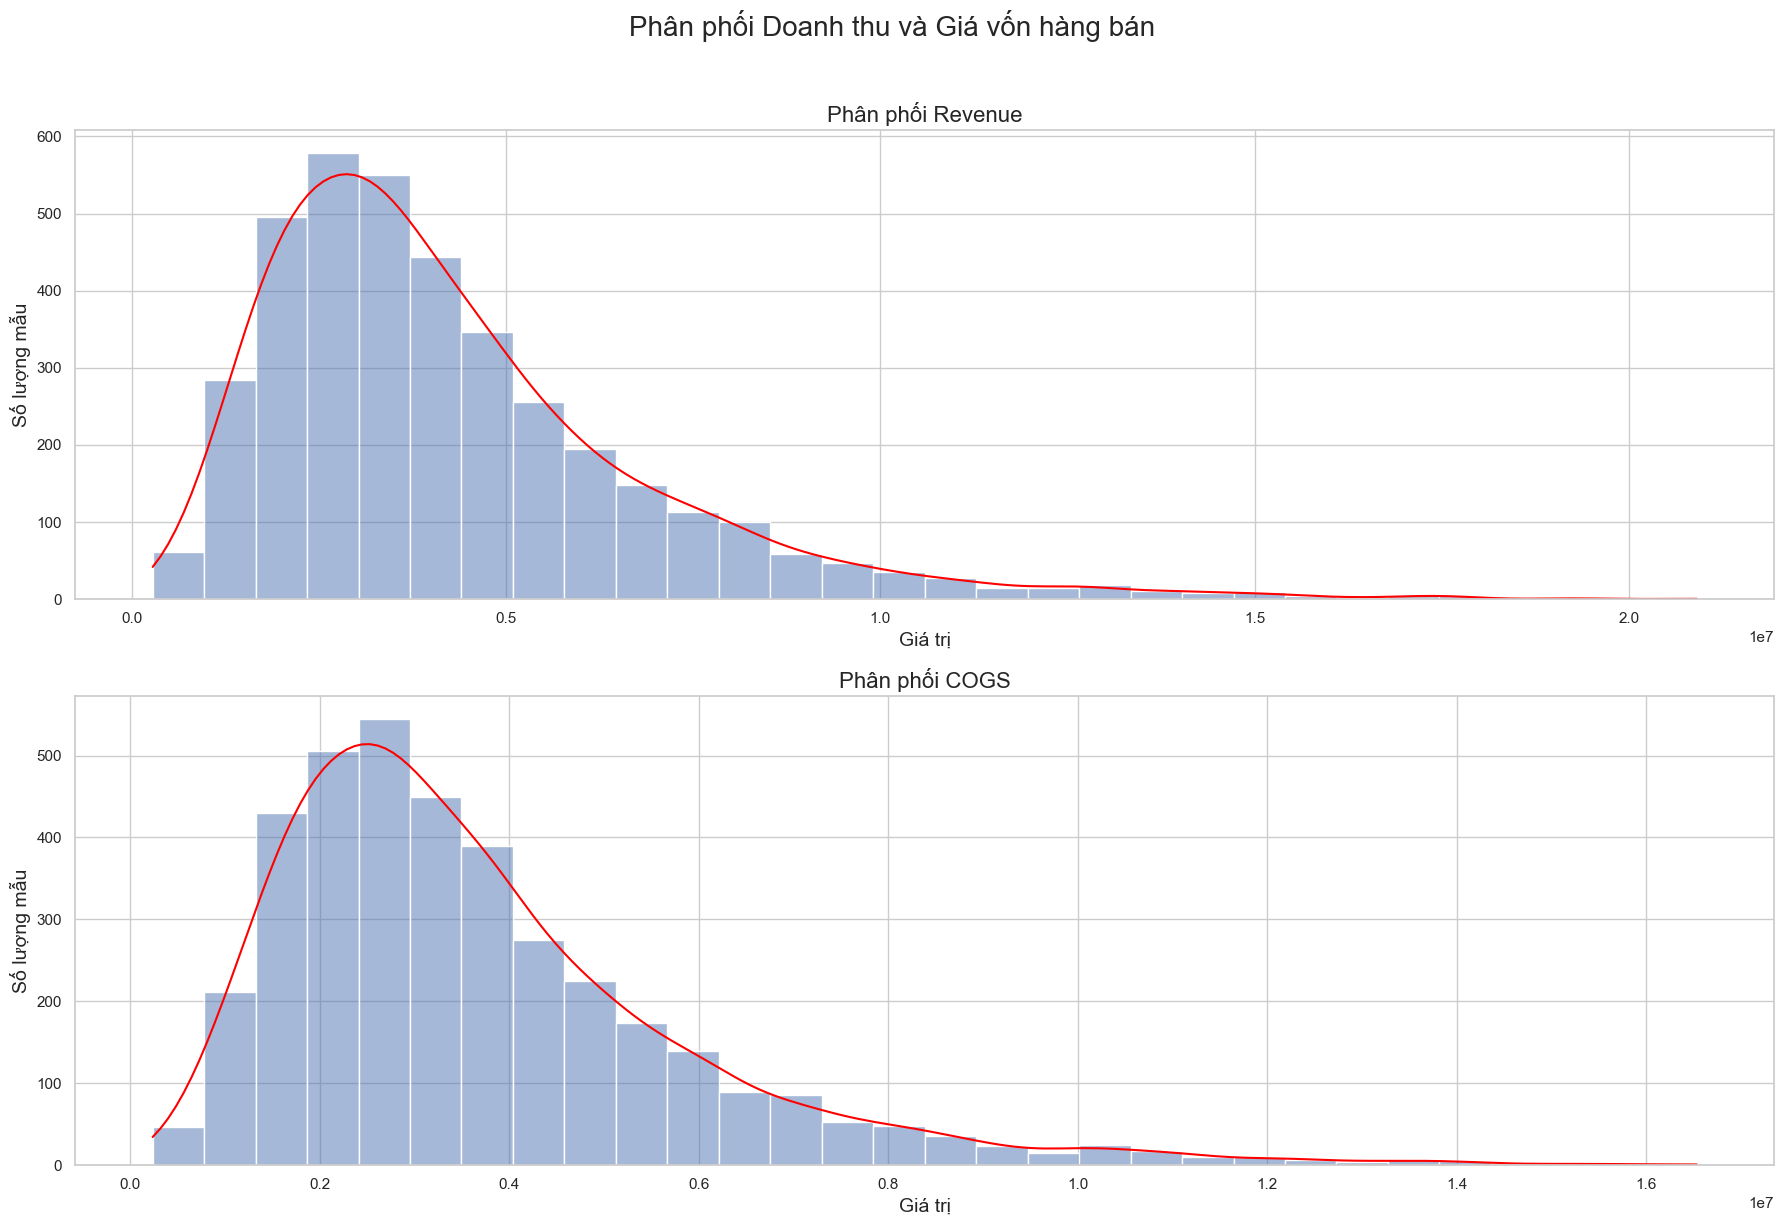

In [ ]:
def plot_distribution(df, columns, title, xlabel, ylabel):
    num_cols = len(columns)
    fig, axes = plt.subplots(num_cols, 1, figsize=(18, 6 * num_cols))
    
    for i, col in enumerate(columns):
        ax = sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
        if ax.lines:
            ax.lines[0].set_color('red')
        axes[i].set_title(f'Phân phối {col}', fontsize=16)
        axes[i].set_xlabel(xlabel, fontsize=14)
        axes[i].set_ylabel(ylabel, fontsize=14)
    
    fig.suptitle(title, fontsize=20, y=1.02)
    fig.tight_layout()
    plt.show()

plot_distribution(sales_df, ['Revenue', 'COGS'], 'Phân phối Doanh thu và Giá vốn hàng bán', 'Giá trị', 'Số lượng mẫu')

**Nhận xét:**

- **Quan sát:**
    - **Phân phối Doanh thu (Revenue):** Dữ liệu có dạng phân bố lệch phải (right-skewed) rất rõ rệt. Phần lớn các quan sát tập trung ở dải giá trị từ thấp đến trung bình (đỉnh tần suất cao nhất rơi vào khoảng 2.5 đến 3.5 triệu). Từ mốc 5 triệu trở đi, số lượng mẫu giảm dần và tạo thành một phần đuôi (long tail) kéo dài đến mức 20 triệu.
    - **Phân phối Giá vốn hàng bán (COGS):** Tương tự như Revenue, phân bố của COGS cũng lệch phải mạnh. Điểm tập trung dữ liệu dày đặc nhất nằm ở mốc thấp hơn một chút (khoảng 2 đến 2.5 triệu) và dải đuôi kéo dài tới mức xấp xỉ 16 triệu.
    - **Tổng quan:** Hình dáng của hai biểu đồ (cả histogram và đường cong mật độ KDE màu đỏ) có độ tương đồng cực kỳ cao. Các đỉnh và độ dốc của hai đường phân phối gần như "copy" lẫn nhau, chỉ khác biệt về thang đo giá trị (trục X của Revenue kéo dài và lớn hơn COGS).

- **Insights:**
    - **Tính chất tập trung**: Mô hình kinh doanh này được đặc trưng bởi số lượng lớn các giao dịch (hoặc ngày bán hàng) có mức doanh thu và giá vốn vừa và nhỏ. Các mức doanh thu "khủng" (trên 15 triệu) rất hiếm khi xảy ra, mang tính chất đột biến hoặc phụ thuộc vào sự kiện đặc biệt.
    - **Tương quan tuyến tính và Biên lợi nhuận**: Sự giống nhau về hình dáng phân phối chứng tỏ Revenue và COGS có sự tương quan dương rất chặt chẽ. Khoảng cách dịch chuyển giữa đỉnh của Revenue và đỉnh của COGS phản ánh tỷ suất lợi nhuận gộp (Gross Margin) trung bình khá ổn định trên phần lớn các điểm dữ liệu.
    - **Lưu ý về xử lý dữ liệu**: Cả hai tập dữ liệu đều vi phạm giả định phân phối chuẩn (Normal Distribution) do độ lệch phải mạnh. Nếu đưa trực tiếp các biến này vào các thuật toán Machine Learning tuyến tính, kết quả có thể bị chệch (bias) do mô hình nhạy cảm với các điểm dữ liệu lớn ở phần đuôi.

- **Gợi ý hành động:** 
    
    - **Phân tích chẩn đoán 2 biến (Bivariate/Diagnostic):** Vẽ ngay biểu đồ phân tán (Scatter Plot) giữa Revenue và COGS để đánh giá biên lợi nhuận. Cần khoanh vùng và "drill-down" vào những điểm dữ liệu ở phần đuôi dài (doanh thu > 10 triệu): Liệu tỷ lệ biên lợi nhuận ở các giao dịch lớn này có được giữ vững, hay COGS bị đội lên quá cao do phải chiết khấu/giảm giá sâu để đạt được khối lượng lớn?
    - **Phân tích đa biến tối ưu danh mục (Multivariate/Prescriptive):** Kết hợp thêm các chiều dữ liệu (dimensions) như "Nhóm sản phẩm", "Chiến dịch Marketing", hoặc "Kênh phân phối" để xem yếu tố nào đang đóng góp chính vào vùng doanh thu 2.5 - 3.5 triệu (vùng an toàn) và yếu tố nào tạo ra các điểm đột biến ở phần đuôi. Từ đó, tối ưu hóa cơ cấu sản phẩm (Product Mix) để gia tăng khoảng cách giữa hai đường phân phối (tăng biên lợi nhuận gộp).
    - **Tiền xử lý cho Mô hình dự báo (Predictive):** Khi xây dựng các mô hình dự báo doanh thu hoặc chi phí (ví dụ: Linear Regression, ARIMA), bắt buộc phải áp dụng phép biến đổi toán học (Log Transformation hoặc Box-Cox Transformation) cho cả biến Revenue và COGS để giảm độ lệch (skewness), đưa dữ liệu về dạng tiệm cận phân phối chuẩn, giúp mô hình học nhanh và hội tụ chính xác hơn.

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

So revenue với những biến trong bảng khác.
